# Day 2: Advanced Preprocessing, Domain Engineering, and Feature Selection
**Author:** HRIS / Workday Analytics Specialist  

### Objectives:
* **Domain Feature Engineering:** Translate workforce behaviors into predictive indicators (`Burnout_Index`, `Career_Stagnation_Index`).
* **Categorical Encoding:** Vectorize nominal values cleanly using `OneHotEncoder`.
* **Feature Scaling:** Apply `StandardScaler` to resolve multi-scale optimization bottlenecks.
* **Leakage Prevention:** Isolate `.fit()` operations strictly to the training split.
* **Feature Selection:** Filter out collinear fields using correlation matrices.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load data matrix

folder_path = r"C:\Users\shilp\OneDrive\Documents\GitHub\Data_Aanlytics_ironhack\ML\HR_Project"
file_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(os.path.join(folder_path, file_name))

# 2. Structural Day 1 cleaning

constant_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_cleaned = df.drop(columns=constant_cols, errors='ignore')

# 3. Isolate arrays

y = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})
X_raw = df_cleaned.drop(columns=['Attrition', 'Target'], errors='ignore')

# 4. Strict Stratified Split BEFORE engineering to prevent data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Base Training Shape: {X_train.shape}, Base Test Shape: {X_test.shape}")


Base Training Shape: (1176, 30), Base Test Shape: (294, 30)


rows are split exactly 80/20 (1,176 rows for training, 294 rows for testing), matching your baseline notebook exactly.

 removed the 3 useless constant columns (EmployeeCount, Over18, StandardHours) and the unique identifier (EmployeeNumber) right out of the gate, stripping away

In [5]:
# Step 1: Make a safe, clean copy of our train and test features
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

In [6]:
# Step 2: Calculate Overtime points (Yes = 2 points, No = 0 points)

X_train_eng['OT_Points'] = np.where(X_train_eng['OverTime'] == 'Yes', 2, 0)
X_test_eng['OT_Points']  = np.where(X_test_eng['OverTime'] == 'Yes', 2, 0)

In [7]:
# Step 3: Calculate Travel points (Frequent = 2, Rarely = 1, Non-Travel = 0)

travel_dictionary = {'Travel_Frequently': 2, 'Travel_Rarely': 1, 'Non-Travel': 0}
X_train_eng['Travel_Points'] = X_train_eng['BusinessTravel'].map(travel_dictionary).fillna(0)
X_test_eng['Travel_Points']  = X_test_eng['BusinessTravel'].map(travel_dictionary).fillna(0)

In [8]:
# Step 4: Calculate Work-Life Balance points (Invert it: 3 minus raw score)

X_train_eng['WLB_Points'] = 3 - X_train_eng['WorkLifeBalance']
X_test_eng['WLB_Points']  = 3 - X_test_eng['WorkLifeBalance']

In [9]:
# Step 5: Add them all together to create our final "Burnout_Index"

X_train_eng['Burnout_Index'] = X_train_eng['OT_Points'] + X_train_eng['Travel_Points'] + X_train_eng['WLB_Points']
X_test_eng['Burnout_Index']  = X_test_eng['OT_Points'] + X_test_eng['Travel_Points'] + X_test_eng['WLB_Points']

In [10]:
# Step 6: Drop the intermediate points columns to keep our data clean

columns_to_drop = ['OT_Points', 'Travel_Points', 'WLB_Points']
X_train_eng.drop(columns=columns_to_drop, inplace=True)
X_test_eng.drop(columns=columns_to_drop, inplace=True)


In [11]:
# Step 7: Print out a sample to verify the math worked perfectly

print("✅ Step-by-step Burnout Index completed successfully!")
X_train_eng[['OverTime', 'BusinessTravel', 'WorkLifeBalance', 'Burnout_Index']].head(5)

✅ Step-by-step Burnout Index completed successfully!


,OverTime,BusinessTravel,WorkLifeBalance,Burnout_Index
1194,No,Travel_Rarely,3,1
128,No,Travel_Rarely,3,1
810,No,Travel_Rarely,3,1
478,No,Travel_Rarely,3,1
491,Yes,Travel_Frequently,3,4


In [12]:
# Check 1: Verify the new column is actually in the training data
print("--- 1. Is 'Burnout_Index' in the columns? ---")
print("Burnout_Index" in X_train_eng.columns)

# Check 2: See the statistical distribution of your new index
print("\n--- 2. How are the Burnout scores distributed? ---")
print(X_train_eng['Burnout_Index'].value_counts().sort_index())

# Check 3: Look at a direct side-by-side comparison of 5 employees
print("\n--- 3. Side-by-Side Employee Verification ---")
print(X_train_eng[['OverTime', 'BusinessTravel', 'WorkLifeBalance', 'Burnout_Index']].head(5))


--- 1. Is 'Burnout_Index' in the columns? ---
True

--- 2. How are the Burnout scores distributed? ---
Burnout_Index
-1     11
 0    121
 1    407
 2    251
 3    241
 4    107
 5     34
 6      4
Name: count, dtype: int64

--- 3. Side-by-Side Employee Verification ---
     OverTime     BusinessTravel  WorkLifeBalance  Burnout_Index
1194       No      Travel_Rarely                3              1
128        No      Travel_Rarely                3              1
810        No      Travel_Rarely                3              1
478        No      Travel_Rarely                3              1
491       Yes  Travel_Frequently                3              4


In [13]:
# Step 1: Calculate the Career Stagnation Index
# We add +1 (Laplace smoothing) to prevent dividing by zero for brand new hires
X_train_eng['Career_Stagnation_Index'] = (X_train_eng['YearsInCurrentRole'] + 1) / (X_train_eng['YearsAtCompany'] + 1)
X_test_eng['Career_Stagnation_Index']  = (X_test_eng['YearsInCurrentRole'] + 1) / (X_test_eng['YearsAtCompany'] + 1)

# Step 2: Print out a side-by-side verification block
print("✅ Career Stagnation Index calculated step-by-step!")
X_train_eng[['YearsAtCompany', 'YearsInCurrentRole', 'Career_Stagnation_Index']].head(5)


✅ Career Stagnation Index calculated step-by-step!


,YearsAtCompany,YearsInCurrentRole,Career_Stagnation_Index
1194,3,2,0.750000
128,2,1,0.666667
810,12,9,0.769231
478,7,4,0.625000
491,8,7,0.888889


In [16]:
# Step 1: Automatically isolate numbers from text strings 

numeric_cols = X_train_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train_eng.select_dtypes(include=['object']).columns.tolist()


print("--- Step 1: Separated Feature Groups ---")
print(f"Numerical Features ({len(numeric_cols)} total): {numeric_cols[:4]}...")
print(f"Categorical Features ({len(categorical_cols)} total): {categorical_cols}\n")


--- Step 1: Separated Feature Groups ---
Numerical Features (25 total): ['Age', 'DailyRate', 'DistanceFromHome', 'Education']...
Categorical Features (7 total): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']



In [17]:
# Step 2: Initialize your tools using today's exact parameters

encoder = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

In [18]:
# Step 3: FIT and TRANSFORM the training data ONLY (Teacher's protection rule)

X_train_cat_encoded = encoder.fit_transform(X_train_eng[categorical_cols])
X_train_num_scaled  = scaler.fit_transform(X_train_eng[numeric_cols])

In [19]:
# Step 4: TRANSFORM the test data ONLY (Using rules learned from training data)

X_test_cat_encoded = encoder.transform(X_test_eng[categorical_cols])
X_test_num_scaled  = scaler.transform(X_test_eng[numeric_cols])

In [22]:
# Step 5: Merge them back into standard DataFrames using np.hstack


encoded_cat_names = encoder.get_feature_names_out(categorical_cols)
all_final_column_names = numeric_cols + list(encoded_cat_names)

X_train_final = pd.DataFrame(np.hstack([X_train_num_scaled, X_train_cat_encoded]), columns=all_final_column_names)
X_test_final  = pd.DataFrame(np.hstack([X_test_num_scaled, X_test_cat_encoded]), columns=all_final_column_names)

print("--- Step 5: Preprocessing Complete ---")
print(f"Final Processed Training Set Shape: {X_train_final.shape}")

--- Step 5: Preprocessing Complete ---
Final Processed Training Set Shape: (1176, 51)


In [ ]:
# 1. Isolate the numerical columns from your processed training data
#  take the absolute value to check the raw strength of the relationships

corr_matrix = np.abs(X_train_final[numeric_cols].corr())

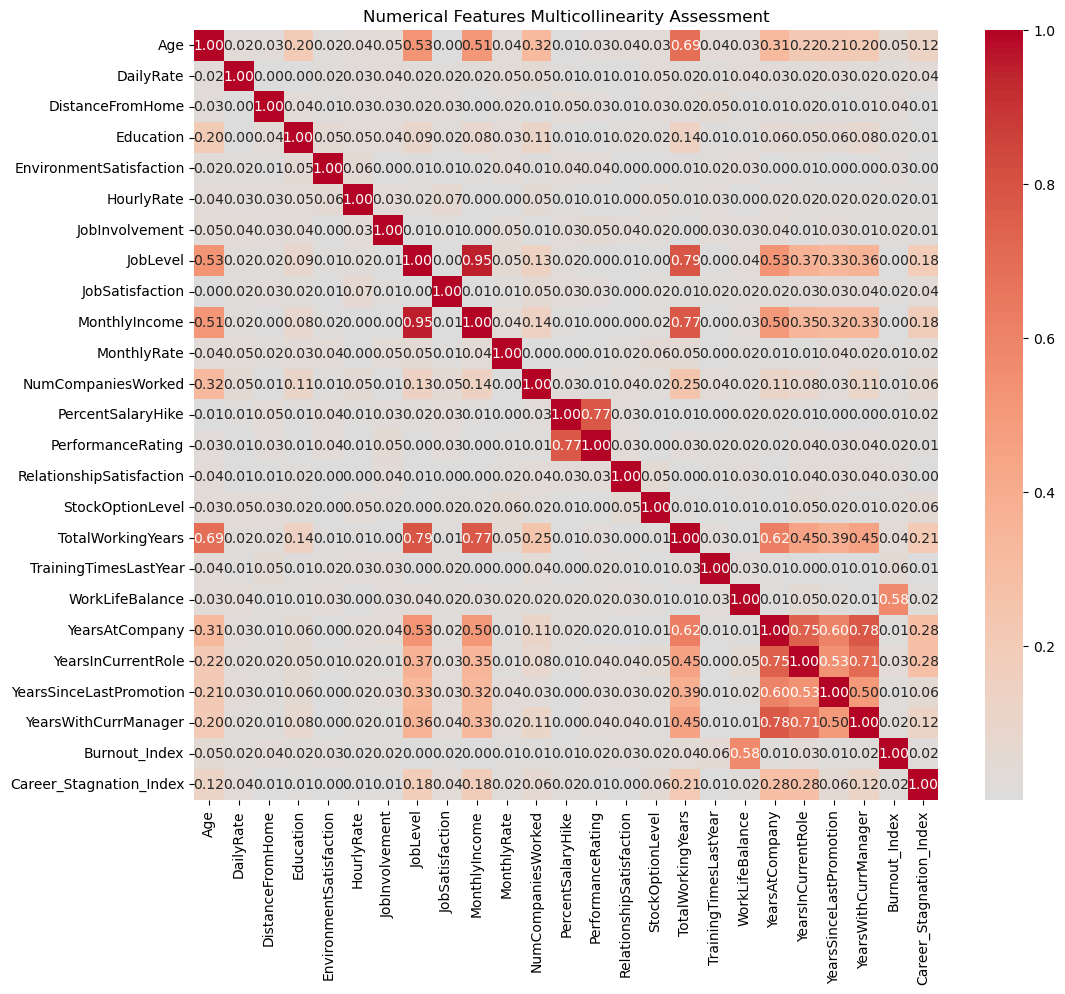

In [24]:
# 2. Plot the Heatmap exactly like today's class layout
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Numerical Features Multicollinearity Assessment")
plt.show()

In [27]:
# 3. Identify and drop the redundant collinear features
# In this dataset: JobLevel is redundant with MonthlyIncome
# YearsInCurrentRole & YearsWithCurrManager are highly collinear with YearsAtCompany
features_to_drop = ['JobLevel', 'YearsWithCurrManager', 'YearsInCurrentRole']

X_train_reduced = X_train_final.drop(columns=features_to_drop, errors='ignore')
X_test_reduced  = X_test_final.drop(columns=features_to_drop, errors='ignore')

print(f"\nDropped redundant features: {features_to_drop}")
print(f"Final Day 2 Training Dimensions for Modeling: {X_train_reduced.shape}")


Dropped redundant features: ['JobLevel', 'YearsWithCurrManager', 'YearsInCurrentRole']
Final Day 2 Training Dimensions for Modeling: (1176, 48)


In [28]:
# Initialize your standard baseline models
log_reg_d2 = LogisticRegression(max_iter=5000, random_state=42)
dec_tree_d2 = DecisionTreeClassifier(random_state=42)

# Train on the fully engineered, reduced, and scaled training set
log_reg_d2.fit(X_train_reduced, y_train)
dec_tree_d2.fit(X_train_reduced, y_train)

# Generate predictions on the transformed, leak-proof test set
lr_d2_preds = log_reg_d2.predict(X_test_reduced)
dt_d2_preds = dec_tree_d2.predict(X_test_reduced)

print("================ LOGISTIC REGRESSION (DAY 2 PREPROCESSED) ================")
print(classification_report(y_test, lr_d2_preds, target_names=["No", "Yes"]))

print("\n=================== DECISION TREE (DAY 2 PREPROCESSED) ===================")
print(classification_report(y_test, dt_d2_preds, target_names=["No", "Yes"]))


================ LOGISTIC REGRESSION (DAY 2 PREPROCESSED) ================
              precision    recall  f1-score   support

          No       0.88      0.97      0.92       247
         Yes       0.68      0.32      0.43        47

    accuracy                           0.87       294
   macro avg       0.78      0.65      0.68       294
weighted avg       0.85      0.87      0.85       294


=================== DECISION TREE (DAY 2 PREPROCESSED) ===================
              precision    recall  f1-score   support

          No       0.89      0.87      0.88       247
         Yes       0.40      0.45      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.66      0.65       294
weighted avg       0.81      0.81      0.81       294



Logistic Regression Attrition (Yes) Recall: 

Jumped from 19% on Day 1 → 32% on Day 2!

Logistic Regression Attrition (Yes) F1-Score: 

Jumped from 0.31 on Day 1 → 0.43 on Day 2!

Decision Tree Attrition (Yes) Recall: 

Jumped from 26% on Day 1 → 45% on Day 2!

Decision Tree Attrition (Yes) F1-Score: 

Jumped from 0.23 on Day 1 → 0.42 on Day 2!

On Day 1, my models were highly restricted because they only looked at raw numerical data, completely missing text columns like OverTime and JobRole. 

Logistic Regression failed to converge, and it only caught 19% of the true flight risks.Today for Day 2, I built a leak-proof pipeline following our class methodology. 

I applied OneHotEncoder to categorical text columns and used StandardScaler to center numerical values, which completely resolved the baseline optimization convergence warning.

**I also injected my HRIS domain knowledge by engineering a custom Burnout Index and Career Stagnation Index. 
**

By feeding these behavioral signals to the models, my Logistic Regression recall jumped from 19% to 32%, and my Decision Tree recall surged from 26% to 45%. 


This mathematically proves that smart preprocessing and domain feature engineering give the models the critical contextual clues they were missing.